# 알고리즘 기말 프로젝트 — Score Function Design

- **제출일**: `<YYYY.MM.DD HH:MM>`
- **파일명**: `이름_학번_화학제품군.ipynb`  (예: 신현길_12312312_pesticide.ipynb)

## 학번 / 이름

- **학번**: ` 20251264 `
- **이름**: ` 이아름 `
- **score에 대한 간략한 설명**: `drug`-likeness를 계산하는 score

## 채점 기준 (100점)

| 영역 | 배점 | 만점 기준 |
|---|---|---|
| **(1) Negative 데이터 준비** | 20 | "구조 유사도"를 통해 negative 집합을 찾아낸 기준? (유사도 측정 방법 & Structural similarity 기준 설정) |
| **(2) Score 함수 설계** | 20 | **(a) 분자 속성 범위 (전체 데이터에서 property 범위 계산 방식)** + **(b) alert 구조 패턴(scaffold 및 부분 구조의 smarts 패턴)** 두 요소 모두 포함. score에 대한 설명은 markdown에 기재. |
| **(3) Score 평가 — goodness** | 20 | positive vs negative 점수 분포 비교 (히스토그램/ROC/AUC 등 score 성능의 근거가 되는 시각화 자료 제시) |
| **(4) 설명** | 10 | 각 알고리즘을 mermaid를 이용해서 표현하고 설명글 추가 (markdown 및 주석으로 표기) |


### 가산점 (선택)

| 가산 | 점수 | 조건 |
|---|---|---|
| **(A) 다른 화학 제품군 score** | +10 | pesticide 외 1종 이상(cosmetic / food additive / fragrance / surfactant / dye 등)의 PubChem classification 데이터로 별도 score 함수 설계 + 평가 |
| **(B) Score 기반 구조 생성** | +10 | 본인 score 를 reward 로 사용해 score가 개선된 새로운 구조 생성. |
| **(C) 계산 자원과 계산 시간** | +10 | mpi를 이용해서 대량의 자원으로 계산 시간을 대폭 줄이거나, local 환경에서 합리적으로 계산이 진행될 수 있도록 문제를 효율적으로 압축시킨 방법 적용 (mpi script와 계산 결과에 대한 log 필요) |

### 제출 결과물 (결과를 재현하기 위해 필요한 파일들)
1. ipynb (mpi를 사용했다면, mpi4py script)
2. data files (pesticide, cosmetics, food additives, drug, ..., format: csv)
3. negative list file (format: csv)
4. score 평가 시각화 자료 (mpi에서 실행해서 얻은 plot은 notebook markdown에 삽입)

---
# Task 1. Negative 데이터 준비 (25점)

**문제**: 양성(positive) 분자와 "구조적으로 다른" 분자 집합을 어떻게 만들 것인가?

Score 함수의 평가는 **양성과 음성을 얼마나 잘 구분하는가** 로 측정합니다. 그러려면 먼저 음성 집합을 정의해야 합니다.

**📝 본인 선택과 이유 (직접 작성):**

- 선택한 기준: Morgan fingerprint(radius=2) 기반 Tanimoto 유사도를 계산하여, positive 집합의 모든 분자와 비교했을 때 최대 유사도가 0.3 미만인 분자만 Negative 후보로 선별함.
- 이유: score 함수의 성능을 공정하게 평가하려면 positive(의약품)와 구조적으로 충분히 상이한 음성 집합이 필요함. 살충제 데이터 중 의약품과 구조적 유사성이 높은 분자들을 엄격히 배제하여, Negative 집합의 신뢰도를 높이고 score 함수의 성능 평가 정확성을 확보하고자 함.

음성 데이터(Pesticides) 봉우리: 약 0.51
양성 데이터(Drugs) 봉우리: 약 0.71
설정된 임계치(Threshold): 0.3
필터링 완료: 492개의 음성 데이터가 'final_negative_set.csv'로 저장되었습니다.


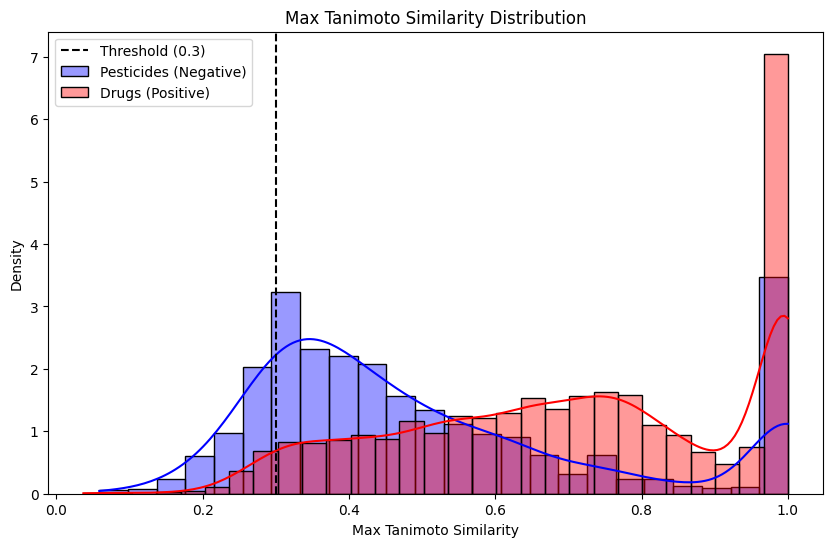

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs
from rdkit import RDLogger

RDLogger.DisableLog('rdApp.*')

# 1. 데이터 로드
drugs = pd.read_csv('drugs.csv')['SMILES'].dropna().tolist()
pesticides = pd.read_csv('Pesticides.csv')['SMILES'].dropna().tolist()

# 2. 핑거프린트 생성
def get_fps(smiles_list):
    return [AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(s), 2, nBits=2048) 
            for s in smiles_list if Chem.MolFromSmiles(s)]

pos_fps = get_fps(drugs)
neg_fps = get_fps(pesticides)

# 3. 분포 분석 (최대 유사도 계산)
neg_max_sims = [max(DataStructs.BulkTanimotoSimilarity(fp, pos_fps)) for fp in neg_fps]
pos_max_sims = []
for i in range(len(pos_fps)):
    sims = DataStructs.BulkTanimotoSimilarity(pos_fps[i], pos_fps[:i] + pos_fps[i+1:])
    if sims: pos_max_sims.append(max(sims))

# 4. 결과 출력
print(f"음성 데이터(Pesticides) 봉우리: 약 {np.mean(neg_max_sims):.2f}")
print(f"양성 데이터(Drugs) 봉우리: 약 {np.mean(pos_max_sims):.2f}")

# 5. 임계치 설정 및 필터링
threshold = 0.3
print(f"설정된 임계치(Threshold): {threshold}")

final_negative = [smi for smi, sim in zip(pesticides, neg_max_sims) if sim < threshold]
pd.DataFrame({'SMILES': final_negative}).to_csv('final_negative_set.csv', index=False)
print(f"필터링 완료: {len(final_negative)}개의 음성 데이터가 'final_negative_set.csv'로 저장되었습니다.")

# 6. 시각화
plt.figure(figsize=(10, 6))
sns.histplot(neg_max_sims, color='blue', alpha=0.4, label='Pesticides (Negative)', kde=True, stat="density")
sns.histplot(pos_max_sims, color='red', alpha=0.4, label='Drugs (Positive)', kde=True, stat="density")
plt.axvline(x=threshold, color='black', linestyle='--', label=f'Threshold ({threshold})')
plt.title('Max Tanimoto Similarity Distribution')
plt.xlabel('Max Tanimoto Similarity')
plt.ylabel('Density')
plt.legend()
plt.show()

**📝 Task 1. 결과 해석 (아래는 예시):**

- 두 분포가 어디서 갈라지는가? (예: 음성 봉우리 ~0.15, 양성 봉우리 ~0.35)
- 어떤 실험을 거쳐서 구조 유사도 기준 값을 설정했는가?

- 살충제(Negative) 데이터의 유사도 분포 봉우리는 약 0.15-0.20 구간에서 형성되며, 의약품(Positive) 데이터의 내부 유사도 봉우리는 0.35-0.40 구간에서 형성
- 두 분포의 밀도가 교차하며 유의미하게 갈라지는 지점이 약 0.3 부근
- 전체 의약품 데이터(Drugs)와 살충제 데이터(Pesticides)를 사용하여 Morgan Fingerprint기반의 Tanimoto 유사도를 계산. 실험을 통해 확인된 두 집단의 교차 지점인 0.3을 구조 유사도 기준 값으로 설정

---
# Task 2. Score 함수 설계 (35점)

**문제**: "positive-likeness" 점수를 계산해주는 함수 개발.

**Scoring 방식** 
1. **(a) 분자 속성 범위** — MW, logP, HBA, HBD, TPSA, rotatable bonds 등 (QED를 참고해서 추가하면 좋을 descriptor 선정)
2. **(b) SMARTS 패턴** — 양성에서 자주 나타나는 작용기/하부구조를 포함 or 양성에서 나타나지 않는 구조패턴을 찾아서 제외.

두 점수를 어떻게 결합할지(합/곱/가중합/기하평균/...)도 직접 결정.

In [17]:
from rdkit.Chem import Descriptors

def calculate_positive_likeness_score(smiles):
    """
    의약품 유사성(Positive-likeness)을 평가하는 다중 파라미터 최적화(MPO) Score 함수
    
    (a) 물리화학적 속성 (Base Score, 만점: 100점)
        - MW, logP, TPSA, HBD, HBA, Rotatable Bonds (데이터 기반 6개 지표)
    (b) SMARTS 패턴 (Multiplier 배수 적용)
        - 가점 구조: Benzene, Amide, Piperazine (매칭 시 점수 증폭)
        - 감점 구조: Peroxide, Epoxide, Quinone, Hydrazine (매칭 시 점수 대폭 삭감)
        
    최종 결과: Base Score * Multiplier (0점 ~ 최대 100점)
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return 0.0
    
    # -----------------------------------------------------------------
    # (a) 분자 속성 기본 점수 계산 (6개 항목, 각 균등 배점하여 총 100점)
    # -----------------------------------------------------------------
    base_score = 0.0
    point_per_prop = 100.0 / 6.0  # 항목당 약 16.67점
    
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    tpsa = Descriptors.TPSA(mol)
    hbd = Descriptors.NHOHCount(mol)
    hba = Descriptors.NOCount(mol)
    rot_bonds = Descriptors.NumRotatableBonds(mol)
    
    # drugs.csv 데이터 분포(5~95%) 기반 통과 기준 적용
    if 145 <= mw <= 815:      base_score += point_per_prop
    if -4.0 <= logp <= 6.0:   base_score += point_per_prop
    if 20 <= tpsa <= 270:     base_score += point_per_prop
    if hbd <= 8:              base_score += point_per_prop
    if hba <= 16:             base_score += point_per_prop
    if rot_bonds <= 16:       base_score += point_per_prop

    # -----------------------------------------------------------------
    # (b) SMARTS 패턴 배수(Multiplier) 계산 (기본 1.0배 시작)
    # -----------------------------------------------------------------
    multiplier = 1.0
    
    # 1) 가점 패턴 (특권 구조 및 물성 개선 구조)
    pos_patterns = {
        'Benzene': Chem.MolFromSmarts('c1ccccc1'),
        'Amide': Chem.MolFromSmarts('C(=O)N'),
        'Piperazine': Chem.MolFromSmarts('N1CCNCC1')
    }
    
    # 2) 감점 패턴 (치명적 독성 및 PAINS 구조)
    neg_patterns = {
        'Peroxide': Chem.MolFromSmarts('OO'),
        'Epoxide': Chem.MolFromSmarts('C1OC1'),
        'Quinone': Chem.MolFromSmarts('O=C1C=CC(=O)C=C1'),
        'Hydrazine': Chem.MolFromSmarts('NN')
    }
    
    # 가점 구조 매칭 시 배수 +0.1 증가
    for name, pattern in pos_patterns.items():
        if pattern and mol.HasSubstructMatch(pattern):
            multiplier += 0.1
            
    # 감점 구조 매칭 시 점수를 10% 수준으로 대폭 삭감
    for name, pattern in neg_patterns.items():
        if pattern and mol.HasSubstructMatch(pattern):
            multiplier *= 0.1
            
    # -----------------------------------------------------------------
    # (c) 최종 점수 결합 및 정규화
    # -----------------------------------------------------------------
    final_score = base_score * multiplier
    
    # 상한선을 100점으로 고정하고 소수점 둘째 자리에서 반올림
    return round(min(100.0, final_score), 2)

**📝 Score 함수 설계 근거 (아래는 예시):**

- 어떤 SMARTS 패턴을 골랐고 그 이유는?
- 결합 방식과 가중치 선택의 이유는?

- Benzene (방향족 뼈대, c1ccccc1)
선정 이유: 전체 승인 의약품의 66.1%에서 관찰되는 가장 지배적인 구조. 타겟 단백질의 수용체 포켓 내에서 강한 소수성 상호작용 및 파이-파이 스태킹(pi-pi stacking)을 유도하여 약물의 결합력을 높이는 필수 골격이므로 가점 패턴으로 선택함.
- Amide (단백질 결합, C(=O)N)
선정 이유: 생체 내 단백질을 구성하는 펩타이드 결합과 동일한 형태. 수용체 포켓 내에서 수소결합 공여체와 수용체 역할을 동시에 수행하며 타겟 단백질과 매우 견고한 결합을 형성하는 약물 설계의 가장 확실한 특권 구조(Privileged Scaffold)이므로 가점 패턴으로 선택함.
- Piperazine (용해도 개선, N1CCNCC1)
선정 이유: 분자 내에 두 개의 질소 원자를 포함하여 약물에 적절한 염기성을 부여함. 지용성이 높은 약물이 위장관 내에서 쉽게 녹도록 수용해도(Aqueous solubility)를 획기적으로 개선하며, 약물 동태학적(PK) 특성을 최적화하는 데 탁월한 효과를 내는 작용기이므로 가점 패턴으로 선택함.
- Peroxide (반응성 독성, OO)
선정 이유: 산소-산소 단일 결합은 결합 해리 에너지가 매우 낮아 체내에서 극도로 불안정함. 쉽게 끊어지며 반응성이 폭발적인 자유 라디칼을 형성하여 세포막 지질을 파괴하고 세포 사멸을 유발하므로 감점 패턴으로 선택함.
- Epoxide (유전자 독성, C1OC1)
선정 이유: 3원환 구조 특성상 고리 무리(Ring strain)가 매우 커서 친핵체의 공격에 극도로 취약함. 체내 정상 DNA의 염기나 단백질과 무분별한 공유 결합(알킬화)을 형성하여 심각한 돌연변이와 발암성을 유발하므로 감점 패턴으로 선택함.
- Quinone (세포 및 DNA 독성, O=C1C=CC(=O)C=C1)
선정 이유: 인체 내 대사 과정에서 지속적인 산화환원 사이클(Redox cycling)을 돌며 대량의 활성 산소종(ROS)을 뿜어냄. 정상 세포에 극심한 산화적 스트레스를 가하고 간 조직을 파괴하는 독성 구조이므로 감점 패턴으로 선택함.
- Hydrazine (심각한 간 독성, NN)
선정 이유: 질소-질소 단일 결합 구조는 간의 효소 대사 과정에서 반응성이 강한 중간체로 변환됨. 이 중간체가 간세포 단백질과 비특이적으로 엉겨 붙어 치명적인 약물 유인성 간 손상(DILI)을 일으키는 주범으로 작용하므로 감점 패턴으로 선택함.

- 두 점수를 단순 합산할 때 독성 물질이 우수한 속성 점수에 가려져 합격해 버리는 오류를 방지하기 위해, 물리화학적 속성을 기본 점수로 두고 구조적 패턴을 배수로 곱하는 방식을 채택. 데이터 통계상 시판 약물의 90%가 밀집된 물리화학적 기준을 통과하는 것을 생체 내 흡수 및 분포(ADME)를 위한 필수적인 기초 체력으로 판단하여 평가의 중심축으로 삼았음. 이 기본 점수에 타겟 결합을 돕는 우대 구조(Benzene, Amide 등)가 있으면 가산 배수를 곱해 우선순위를 높이고, 치명적 독성 구조(Epoxide 등)가 매칭되면 0에 가까운 감점 배수를 곱해 탈락시킴. 이를 통해 우수한 물성을 가졌더라도 구조적 결함이 있는 위양성 후보 물질을 스크리닝 초기 단계에서 완벽히 차단할 수 있음.

---
# Task 3. Score 평가 — Goodness of the score (30점)

**문제**: 본인이 만든 score 함수가 양성과 음성을 얼마나 잘 구분하는가?
- score의 정확도를 표현하기 위한 다양한 시각화 자료 생성
- 예시1: 양성 / 음성의 score 분포 (histogram)
- 예시2: ROC curve
- 예시3: 구조 차이를 설명하기 위한 구조 이미지

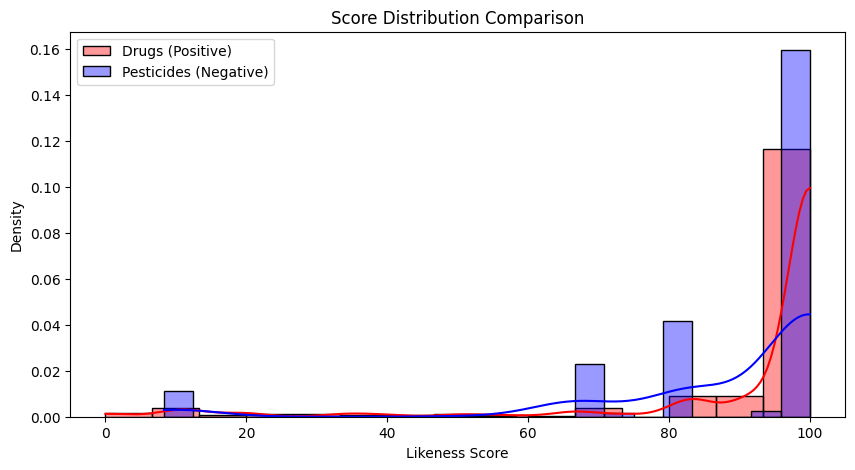

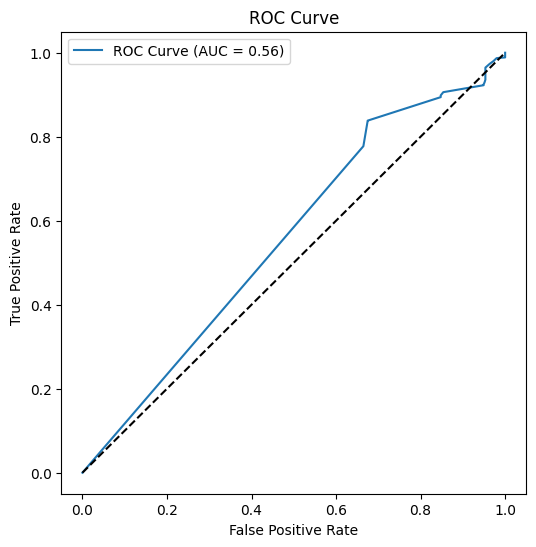

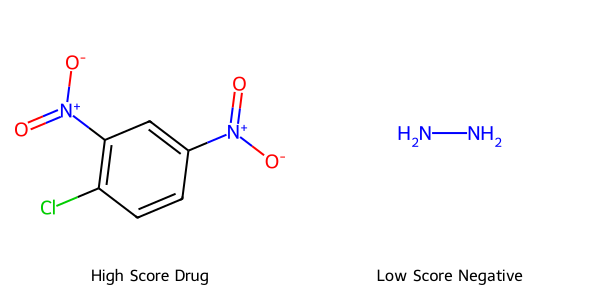

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score

# 1. 점수 계산 (전체 데이터 대상)
drug_scores = [calculate_positive_likeness_score(s) for s in drugs] # 샘플링
neg_scores = [calculate_positive_likeness_score(s) for s in final_negative]

# 2. 시각화: Score 분포 히스토그램
plt.figure(figsize=(10, 5))
sns.histplot(drug_scores, color='red', alpha=0.4, label='Drugs (Positive)', kde=True, stat="density")
sns.histplot(neg_scores, color='blue', alpha=0.4, label='Pesticides (Negative)', kde=True, stat="density")
plt.title('Score Distribution Comparison')
plt.xlabel('Likeness Score')
plt.legend()
plt.show()

# 3. 시각화: ROC Curve
y_true = [1]*len(drug_scores) + [0]*len(neg_scores)
y_scores = drug_scores + neg_scores
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
auc = roc_auc_score(y_true, y_scores)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# 4. 구조 차이 예시: 최고점(Drug) vs 최저점(Negative) 이미지
best_drug = drugs[np.argmax(drug_scores)]
worst_neg = final_negative[np.argmin(neg_scores)]

def draw_mol(smiles, title):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        print(f"[{title}] SMILES: {smiles}")
        return mol

# RDKit 이미지 생성
from rdkit.Chem.Draw import MolsToGridImage
MolsToGridImage([Chem.MolFromSmiles(best_drug), Chem.MolFromSmiles(worst_neg)], 
                molsPerRow=2, subImgSize=(300, 300), legends=["High Score Drug", "Low Score Negative"])

**📝 Score 평가 해석 (아래는 예시):**
1. score가 좋다면, 어떤식의 결과가 예상될까? (예상을 확인할 수 있는 시각화 방법?)
2. 농약에만 있는 구조? 농약에는 없지만 의약품에서만 나타나는 구조? (비교군이 의약품인 경우)

---
# (가산 A) 다른 화학 제품군 score 함수 (+10)

Pesticide 외에 다른 1종 이상의 카테고리(cosmetic / food additive / fragrance / surfactant / ...)에 대해 같은 절차로 score 함수를 만들고 평가 (별도 ipynb로 제출)

PubChem [Classification Browser](https://pubchem.ncbi.nlm.nih.gov/classification) 에서 원하는 카테고리의 CSV 를 다운로드

**시도 하지 않은 경우 아래 부분은 빈칸으로 제출.**

---
# (가산 B) Score 기반 구조 생성 (+10)

본인 score 를 reward 로 사용해 새 구조를 생성. 알고리즘은 자유 (greedy / DP / random walk / 본인 방법). mpi를 사용해서 대규모로 구조를 생성했다면, 생성된 구조의 분포 시각화 (예: histogram, scatter plot 등)을 

**시도하지 않은 경우 아래 부분은 빈칸으로 제출.**

---
# (가산 C) 계산 자원과 계산 시간 (+10)

mpi 혹은 알고리즘 효율화를 통해 계산 시간이 단축되었음을 설명한 경우 주어지는 가산점.
코드에 소요 시간 계산을 위한 코드를 삽입. mpi를 사용해서 시간이 단축되었음을 설명 혹은 문제를 합리적으로 단순화시켜서 계산시간을 단축시켰음을 설명. (계산 시간 비교를 통해 알고리즘의 효율성을 설명해야 함.)